# Notebook 04 — Hypothesis A: Stability vs market stress

**Hypothesis:** Instability of JM clusters co-moves with **VIX** and **STLFSI** (St. Louis Fed Financial Stress). Strong association supports interpreting shifts as **adaptation** to macro regimes rather than a pure estimation artefact.

**Design:** For each refit date, macro covariates are **training-window means** (same `TRAIN_YEARS` rule as Notebook 03). **HP decomposition** (daily VIX, $\lambda=1.6\times10^6$) supplies a **cycle** level at each refit. **Spearman** + bootstrap CI and asymptotic **p-values**; **Bonferroni** and **Benjamini–Hochberg FDR** correct for the **full grid** of univariate correlations in this notebook (one test per row in `hypothesis_A_correlations.csv`; with 12 assets and pairwise 6 + CVI 6 cells per asset, **m = 144**). **Internal CVIs:** only **Silhouette** and **Davies–Bouldin** vs stress (raw Calinski–Harabasz is omitted here; see Notebook 03 for CH and CH/n). **OLS + HAC** with stress and a linear time trend.


In [1]:
import sys
import warnings
from pathlib import Path

_here = Path.cwd().resolve()
_repo_root = _here
for _ in range(16):
    if (_repo_root / "src" / "config" / "settings.py").is_file():
        break
    if _repo_root.parent == _repo_root:
        raise RuntimeError("Cannot find repo root (src/config/settings.py)")
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.helpers import setup_logging
setup_logging()

RESULTS_DIR = _repo_root / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

from src.config.settings import (
    ASSETS, ASSET_TICKERS, FRED_SERIES,
    DATA_START, DATA_END, TEST_START, TEST_END,
    TRAIN_YEARS,
)
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.cluster_stability import build_pairwise_stability_df, build_internal_validity_df
from src.analysis.time_series_stats import (
    hac_ols,
    spearman_bootstrap_ci,
    macro_mean_in_train_window,
    macro_cycle_at_date,
)

loader = DataLoader()
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)
prep = DataPreprocessor()
excess_returns, rf_daily, fred_aligned = prep.prepare(prices, fred)
idx = excess_returns.index
vix = fred_aligned["vix"].astype(float)
stlfi = fred_aligned["stlfi"].astype(float)
print("Data ready", excess_returns.shape)


2026-04-27 18:09:33 | INFO     | src.data.loader | Loading prices from cache: /home/researcher/app/data/raw/prices_1991-01-01_2023-12-31.pkl
2026-04-27 18:09:33 | INFO     | src.data.loader | Loading FRED data from cache: /home/researcher/app/data/raw/fred_1991-01-01_2023-12-31.pkl
2026-04-27 18:09:33 | INFO     | src.data.preprocessor | event=preprocess_step step=input_prices rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10714
2026-04-27 18:09:33 | INFO     | src.data.preprocessor | event=preprocess_step step=input_fred rows=8608 cols=5 start=1991-01-02 end=2023-12-29 na_count=8582
2026-04-27 18:09:33 | INFO     | src.data.preprocessor | event=preprocess_step step=simple_returns rows=5941 cols=12 start=2000-05-19 end=2023-12-29 na_count=10726
2026-04-27 18:09:33 | INFO     | src.data.preprocessor | event=preprocess_step step=fred_aligned rows=5941 cols=5 start=2000-05-19 end=2023-12-29 na_count=0
2026-04-27 18:09:33 | INFO     | src.data.preprocessor | event=preprocess_st

Data ready (5940, 12)


In [2]:
import pickle

STABILITY_CACHE = RESULTS_DIR / "stability_jm_fits.pkl"
if not STABILITY_CACHE.exists():
    raise FileNotFoundError(
        f"Missing {STABILITY_CACHE}. Run notebook 03 once to build the JM cache."
    )
with open(STABILITY_CACHE, "rb") as f:
    jm_fits = pickle.load(f)

stab_df = build_pairwise_stability_df(jm_fits, ASSETS)
cvi_df = build_internal_validity_df(jm_fits, ASSETS)
cvi_df = cvi_df[cvi_df["has_features"]].copy()
print("pairwise rows", len(stab_df), "cvi rows", len(cvi_df))


pairwise rows 396 cvi rows 408


In [3]:
def stress_for_rebal_dates(dates, macro_vix, macro_stress):
    rows = []
    for d in dates:
        d = pd.Timestamp(d)
        rows.append(
            {
                "Rebal_date": d,
                "vix_mean": macro_mean_in_train_window(d, macro_vix, idx, TRAIN_YEARS),
                "stlfi_mean": macro_mean_in_train_window(d, macro_stress, idx, TRAIN_YEARS),
                "vix_cycle": macro_cycle_at_date(macro_vix, d),
            }
        )
    return pd.DataFrame(rows)

uni_dates = pd.DatetimeIndex(sorted(cvi_df["Rebal_date"].unique()))
stress_panel = stress_for_rebal_dates(uni_dates, vix, stlfi)
cvi_m = cvi_df.merge(stress_panel, on="Rebal_date", how="left")
stab_m = stab_df.merge(stress_panel, left_on="Date_curr", right_on="Rebal_date", how="left")
stab_m["trend_time"] = (stab_m["Date_curr"] - stab_m["Date_curr"].min()).dt.days / 365.25
cvi_m["trend_time"] = (cvi_m["Rebal_date"] - cvi_m["Rebal_date"].min()).dt.days / 365.25
print(cvi_m[["Asset", "Rebal_date", "vix_mean", "silhouette"]].head())


      Asset Rebal_date   vix_mean  silhouette
0  LargeCap 2007-01-03  19.638550    0.349243
1  LargeCap 2007-07-02  19.188555    0.353929
2  LargeCap 2008-01-02  19.362671    0.354560
3  LargeCap 2008-07-01  19.606079    0.356831
4  LargeCap 2009-01-02  20.919940    0.374582


In [4]:
from statsmodels.stats.multitest import multipletests

rows_corr = []
for asset in ASSETS:
    sub = stab_m[stab_m["Asset"] == asset].copy()
    for col_y in ("Agreement", "ARI"):
        for col_x, slug in (
            ("vix_mean", "vix_mean"),
            ("stlfi_mean", "stlfi_mean"),
            ("vix_cycle", "vix_cycle"),
        ):
            rho, lo, hi, p_sp = spearman_bootstrap_ci(
                sub[col_y].values,
                sub[col_x].values,
                n_boot=1500,
                seed=42,
                return_pvalue=True,
            )
            rows_corr.append(
                {
                    "panel": "pairwise",
                    "asset": asset,
                    "y": col_y,
                    "x": slug,
                    "spearman": rho,
                    "ci_lo": lo,
                    "ci_hi": hi,
                    "p_spearman": p_sp,
                    "n": int(sub[[col_y, col_x]].dropna().shape[0]),
                }
            )
    subc = cvi_m[cvi_m["Asset"] == asset].copy()
    for col_y in ["silhouette", "davies_bouldin"]:
        for col_x, slug in (
            ("vix_mean", "vix_mean"),
            ("stlfi_mean", "stlfi_mean"),
            ("vix_cycle", "vix_cycle"),
        ):
            rho, lo, hi, p_sp = spearman_bootstrap_ci(
                subc[col_y].values,
                subc[col_x].values,
                n_boot=1500,
                seed=43,
                return_pvalue=True,
            )
            rows_corr.append(
                {
                    "panel": "cvi",
                    "asset": asset,
                    "y": col_y,
                    "x": slug,
                    "spearman": rho,
                    "ci_lo": lo,
                    "ci_hi": hi,
                    "p_spearman": p_sp,
                    "n": int(subc[[col_y, col_x]].dropna().shape[0]),
                }
            )

corr_tbl = pd.DataFrame(rows_corr)
m_tests = len(corr_tbl)
corr_tbl["n_tests_family"] = m_tests

p_raw = corr_tbl["p_spearman"].to_numpy(dtype=float)
padj_bonf = np.full(m_tests, np.nan)
rej_bonf = np.full(m_tests, np.nan)
padj_fdr = np.full(m_tests, np.nan)
rej_fdr = np.full(m_tests, np.nan)
ok = np.isfinite(p_raw)
if ok.any():
    rb, pb, _, _ = multipletests(p_raw[ok], alpha=0.05, method="bonferroni")
    rf, pf, _, _ = multipletests(p_raw[ok], alpha=0.05, method="fdr_bh")
    padj_bonf[ok] = pb
    rej_bonf[ok] = rb.astype(float)
    padj_fdr[ok] = pf
    rej_fdr[ok] = rf.astype(float)
corr_tbl["p_adjusted_bonferroni"] = padj_bonf
corr_tbl["reject_bonferroni_05"] = rej_bonf
corr_tbl["p_adjusted_fdr_bh"] = padj_fdr
corr_tbl["reject_fdr_bh_05"] = rej_fdr

corr_tbl.to_csv(RESULTS_DIR / "hypothesis_A_correlations.csv", index=False)
print(
    "Saved hypothesis_A_correlations.csv rows",
    len(corr_tbl),
    "| family m =",
    m_tests,
    "| Bonferroni alpha/m =",
    f"{0.05 / m_tests:.6f}",
)
print("Reject Bonferroni @0.05:", int(np.nansum(corr_tbl["reject_bonferroni_05"])))
print("Reject FDR-BH @0.05:", int(np.nansum(corr_tbl["reject_fdr_bh_05"])))


Saved hypothesis_A_correlations.csv rows 144 | family m = 144 | Bonferroni alpha/m = 0.000347
Reject Bonferroni @0.05: 23
Reject FDR-BH @0.05: 37


In [5]:
# HAC regressions: Agreement ~ stress + time (one example per asset); full table to text
lines = []
for asset in ASSETS:
    sub = stab_m[stab_m["Asset"] == asset].dropna(
        subset=["Agreement", "vix_mean", "stlfi_mean", "trend_time"]
    )
    if len(sub) < 10:
        continue
    y = sub["Agreement"].values
    X = sub[["vix_mean", "stlfi_mean", "trend_time"]].values
    res = hac_ols(y, X)
    lines.append(f"\n=== {asset}: Agreement ~ vix_mean + stlfi_mean + time ===\n")
    lines.append(res.summary().as_text())
with open(RESULTS_DIR / "hypothesis_A_regression_agreement_hac.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print("Wrote hypothesis_A_regression_agreement_hac.txt")


Wrote hypothesis_A_regression_agreement_hac.txt


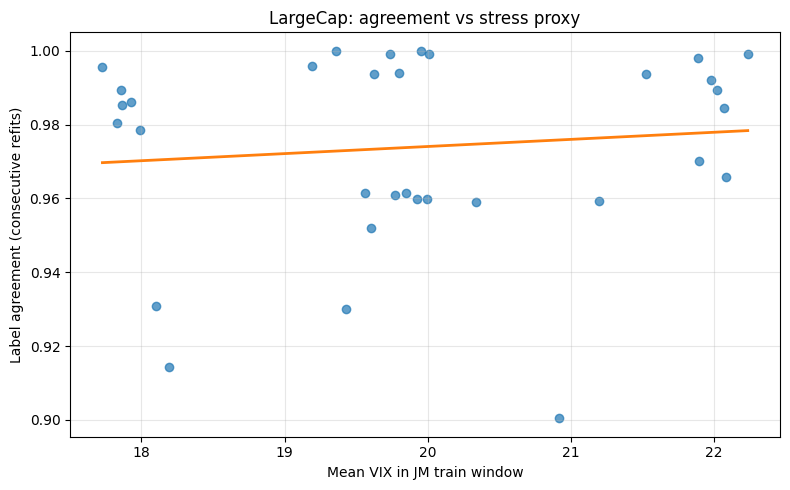

In [6]:
# Example figure: LargeCap Agreement vs VIX (training-window mean)
asset = "LargeCap"
sub = stab_m[stab_m["Asset"] == asset].dropna(subset=["Agreement", "vix_mean"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sub["vix_mean"], sub["Agreement"], alpha=0.7, s=36)
z = np.polyfit(sub["vix_mean"], sub["Agreement"], 1)
ax.plot(np.sort(sub["vix_mean"]), np.poly1d(z)(np.sort(sub["vix_mean"])), color="C1", lw=2)
ax.set_xlabel("Mean VIX in JM train window")
ax.set_ylabel("Label agreement (consecutive refits)")
ax.set_title(f"{asset}: agreement vs stress proxy")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hypothesis_A_scatter_agreement_vix_largecap.png", dpi=150)
plt.show()
